In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Load datasets
data_path = 'data/raw/'
transactions = pd.read_csv(os.path.join(data_path, 'transactions_train.csv'))
articles = pd.read_csv(os.path.join(data_path, 'articles.csv'))
customers = pd.read_csv(os.path.join(data_path, 'customers.csv'))

# Set up visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Transactions: {transactions.shape}")
print(f"Articles: {articles.shape}")
print(f"Customers: {customers.shape}")

Transactions: (31788324, 5)
Articles: (105542, 25)
Customers: (1371980, 7)


In [21]:
print("CUSTOMER PURCHASE ANALYSIS")
print("=" * 70)

# Total purchases per customer
customer_purchases = transactions.groupby('customer_id').size().reset_index(name = 'total_purchases')

print(f"\n1. PURCHASE FREQUENCY:")
print(f" Mean purchases per customer : {customer_purchases['total_purchases'].mean():.2f}")
print(f"   Median purchases per customer: {customer_purchases['total_purchases'].median():.0f}")
print(f"   Min: {customer_purchases['total_purchases'].min()}")
print(f"   Max: {customer_purchases['total_purchases'].max()}")

print(f"\n2. DISTRIBUTION:")
print(f" Customers with one purchases : {(customer_purchases['total_purchases'] == 1).sum():,}")
print(f" Customers with 2 to 10 purchases : {((customer_purchases['total_purchases'] >= 2) & (customer_purchases['total_purchases'] <= 10)).sum():,}")
print(f" Customers with 11 to 50 purchases : {((customer_purchases['total_purchases'] >= 11) & (customer_purchases['total_purchases'] >= 50)).sum():,}")
print(f" Customers with more than 50 purchases : {(customer_purchases['total_purchases'] > 50).sum():,}")

print(f"\n3. Top 10 Customers ")
top_customers = customer_purchases.nlargest(10, 'total_purchases')
for idx, row in top_customers.iterrows():
     print(f"   {row['customer_id'][:20]}... : {row['total_purchases']} purchases")

CUSTOMER PURCHASE ANALYSIS

1. PURCHASE FREQUENCY:
 Mean purchases per customer : 23.33
   Median purchases per customer: 9
   Min: 1
   Max: 1895

2. DISTRIBUTION:
 Customers with one purchases : 131,514
 Customers with 2 to 10 purchases : 588,985
 Customers with 11 to 50 purchases : 175,792
 Customers with more than 50 purchases : 171,242

3. Top 10 Customers 
   be1981ab818cf4ef6765... : 1895 purchases
   b4db5e5259234574edff... : 1441 purchases
   49beaacac0c7801c2ce2... : 1364 purchases
   a65f77281a528bf5c1e9... : 1361 purchases
   cd04ec2726dd58a8c753... : 1237 purchases
   55d15396193dfd45836a... : 1208 purchases
   c140410d72a41ee5e2e3... : 1170 purchases
   8df45859ccd71ef1e48e... : 1169 purchases
   03d0011487606c37c1b1... : 1157 purchases
   6cc121e5cc202d2bf344... : 1143 purchases



QUARTILE ANALYSIS:
0.25     3.0
0.50     9.0
0.75    27.0
0.90    60.0
0.95    91.0
Name: total_purchases, dtype: float64


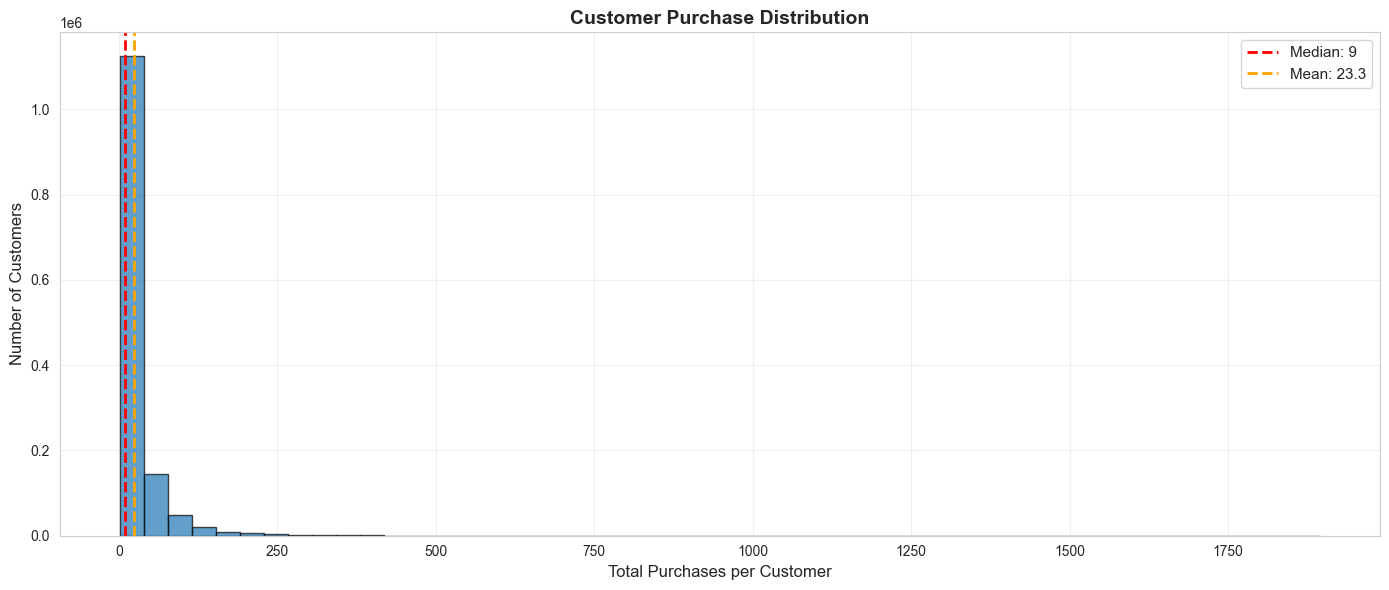


Distribution Shape:
  Skewness: 5.24
  (Positive = right-skewed, many low values + few high values)


In [28]:
print("\nQUARTILE ANALYSIS:")

quartiles = customer_purchases['total_purchases'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
print(quartiles)

# Histogram
plt.figure(figsize=(14, 6))
plt.hist(customer_purchases['total_purchases'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Total Purchases per Customer', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Purchase Distribution', fontsize=14, fontweight='bold')

# Quartile lines
plt.axvline(customer_purchases['total_purchases'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {customer_purchases["total_purchases"].median():.0f}')
plt.axvline(customer_purchases['total_purchases'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {customer_purchases["total_purchases"].mean():.1f}')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDistribution Shape:")
print(f"  Skewness: {customer_purchases['total_purchases'].skew():.2f}")
print(f"  (Positive = right-skewed, many low values + few high values)")

In [29]:
print("\n" + "=" * 70)
print("RECENCY ANALYSIS (Days Since Last Purchase)")
print("=" * 70)

# Convert date to datetime
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Get the last purchase date for each customer
last_purchase = transactions.groupby('customer_id')['t_dat'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']

# Calculate recency (days since last purchase)
reference_date = transactions['t_dat'].max()  # 2020-09-22
last_purchase['recency_days'] = (reference_date - last_purchase['last_purchase_date']).dt.days

print(f"\nReference date: {reference_date.date()}")
print(f"\n1. RECENCY STATISTICS:")
print(f"   Mean days since last purchase: {last_purchase['recency_days'].mean():.1f} days")
print(f"   Median days since last purchase: {last_purchase['recency_days'].median():.0f} days")
print(f"   Min: {last_purchase['recency_days'].min()} days (most recent)")
print(f"   Max: {last_purchase['recency_days'].max()} days (oldest)")

print(f"\n2. RECENCY SEGMENTS:")
print(f"   0-7 days (Last week): {(last_purchase['recency_days'] <= 7).sum():,} customers")
print(f"   8-30 days (Last month): {((last_purchase['recency_days'] > 7) & (last_purchase['recency_days'] <= 30)).sum():,} customers")
print(f"   31-90 days (Last quarter): {((last_purchase['recency_days'] > 30) & (last_purchase['recency_days'] <= 90)).sum():,} customers")
print(f"   90+ days (More than 3 months): {(last_purchase['recency_days'] > 90).sum():,} customers")

print(f"\n3. TOP 10 MOST RECENT CUSTOMERS:")
recent = last_purchase.nsmallest(10, 'recency_days')
for idx, row in recent.iterrows():
    print(f"   {row['customer_id'][:20]}... : {row['recency_days']} days ago")


RECENCY ANALYSIS (Days Since Last Purchase)

Reference date: 2020-09-22

1. RECENCY STATISTICS:
   Mean days since last purchase: 235.1 days
   Median days since last purchase: 151 days
   Min: 0 days (most recent)
   Max: 733 days (oldest)

2. RECENCY SEGMENTS:
   0-7 days (Last week): 75,481 customers
   8-30 days (Last month): 175,138 customers
   31-90 days (Last quarter): 274,456 customers
   90+ days (More than 3 months): 837,206 customers

3. TOP 10 MOST RECENT CUSTOMERS:
   0003e867a930d0d6842f... : 0 days ago
   000525e3fe01600d717d... : 0 days ago
   0010e8eb18f131e724d6... : 0 days ago
   001436e2c83cda28548d... : 0 days ago
   0026ebdd70715d8fa2be... : 0 days ago
   002faf80a68267264102... : 0 days ago
   00357b192b81fc83261a... : 0 days ago
   003bb11f4a641d26e321... : 0 days ago
   0049f94e2289eed627a4... : 0 days ago
   004d932f7a27ac3167c7... : 0 days ago


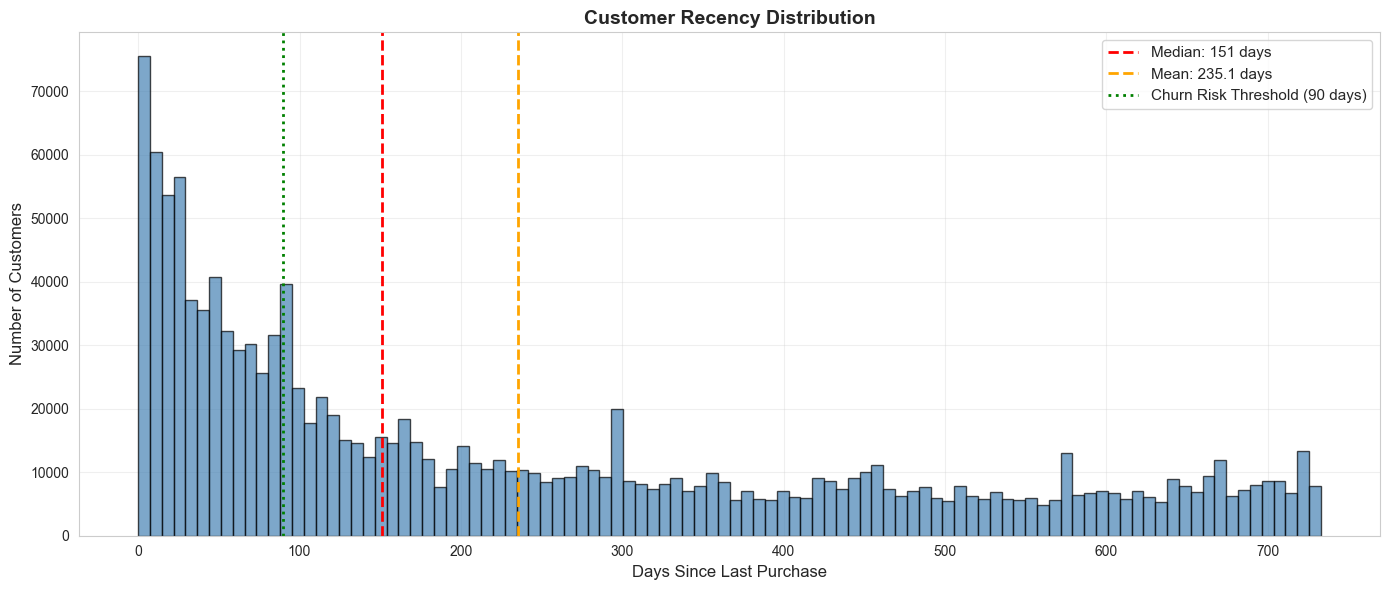

Recency Skewness: 0.80


In [30]:
# Recency histogram
plt.figure(figsize=(14, 6))
plt.hist(last_purchase['recency_days'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Recency Distribution', fontsize=14, fontweight='bold')

# Add reference lines
plt.axvline(last_purchase['recency_days'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {last_purchase["recency_days"].median():.0f} days')
plt.axvline(last_purchase['recency_days'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {last_purchase["recency_days"].mean():.1f} days')

# Add churn threshold
plt.axvline(90, color='green', linestyle=':', linewidth=2, label='Churn Risk Threshold (90 days)')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Recency Skewness: {last_purchase['recency_days'].skew():.2f}")

In [31]:
print("\n" + "=" * 70)
print("RFM SEGMENTATION")
print("=" * 70)

# Merge customer purchase frequency with recency
rfm = customer_purchases.copy()
rfm = rfm.merge(last_purchase[['customer_id', 'recency_days']], on='customer_id')

# Add monetary value
monetary = transactions.groupby('customer_id')['price'].sum().reset_index()
monetary.columns = ['customer_id', 'total_spent']
rfm = rfm.merge(monetary, on='customer_id')

print(f"\nRFM DATA SUMMARY:")
print(f"Customers with RFM data: {len(rfm):,}")
print(f"\nRecency (days since last purchase):")
print(f"  Mean: {rfm['recency_days'].mean():.1f}, Median: {rfm['recency_days'].median():.0f}")
print(f"\nFrequency (total purchases):")
print(f"  Mean: {rfm['total_purchases'].mean():.1f}, Median: {rfm['total_purchases'].median():.0f}")
print(f"\nMonetary (total spent in EUR):")
print(f"  Mean: €{rfm['total_spent'].mean():.2f}, Median: €{rfm['total_spent'].median():.2f}")
print(f"  Min: €{rfm['total_spent'].min():.2f}, Max: €{rfm['total_spent'].max():.2f}")

# RFM Quartile Scores
rfm['R_score'] = pd.qcut(rfm['recency_days'], q=4, labels=[4, 3, 2, 1])  # Lower recency = higher score
rfm['F_score'] = pd.qcut(rfm['total_purchases'].rank(method='first'), q=4, labels=[1, 2, 3, 4])  # Higher frequency = higher score
rfm['M_score'] = pd.qcut(rfm['total_spent'], q=4, labels=[1, 2, 3, 4])  # Higher monetary = higher score

# Convert to int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# RFM Score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(f"\n\nRFM SEGMENTS:")
print(f"Unique RFM combinations: {rfm['RFM_Score'].nunique()}")

# Top RFM segments
print(f"\nTop 10 RFM Segments (by customer count):")
top_segments = rfm['RFM_Score'].value_counts().head(10)
for segment, count in top_segments.items():
    print(f"  Segment {segment}: {count:,} customers")


RFM SEGMENTATION

RFM DATA SUMMARY:
Customers with RFM data: 1,362,281

Recency (days since last purchase):
  Mean: 235.1, Median: 151

Frequency (total purchases):
  Mean: 23.3, Median: 9

Monetary (total spent in EUR):
  Mean: €0.65, Median: €0.25
  Min: €0.00, Max: €57.68


RFM SEGMENTS:
Unique RFM combinations: 60

Top 10 RFM Segments (by customer count):
  Segment 444: 172,732 customers
  Segment 111: 133,027 customers
  Segment 344: 93,310 customers
  Segment 333: 85,271 customers
  Segment 211: 85,267 customers
  Segment 122: 80,841 customers
  Segment 222: 70,110 customers
  Segment 233: 69,231 customers
  Segment 433: 68,470 customers
  Segment 322: 53,093 customers


In [32]:
print("\n" + "=" * 70)
print("RFM SEGMENT INTERPRETATION")
print("=" * 70)

# Define segment names based on RFM scores
def segment_name(r, f, m):
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2:
        return "Loyal Customers"
    elif r >= 2 and f >= 3:
        return "Potential Loyalists"
    elif r >= 3 and m >= 2:
        return "New Customers"
    elif r <= 2 and f >= 3 and m >= 2:
        return "At Risk"
    elif r <= 1 and f >= 2:
        return "Cant Lose Them"
    elif r <= 2 and f >= 2:
        return "Need Attention"
    elif f <= 1:
        return "Lost"
    else:
        return "Other"

rfm['segment_name'] = rfm.apply(lambda row: segment_name(row['R_score'], row['F_score'], row['M_score']), axis=1)

print("\nCUSTOMER SEGMENTS:")
segment_summary = rfm.groupby('segment_name').agg({
    'customer_id': 'count',
    'recency_days': 'mean',
    'total_purchases': 'mean',
    'total_spent': 'mean'
}).round(2)
segment_summary.columns = ['Count', 'Avg Recency (days)', 'Avg Frequency', 'Avg Monetary (€)']
segment_summary = segment_summary.sort_values('Count', ascending=False)
print(segment_summary)

print(f"\n\nPERCENTAGE BREAKDOWN:")
for segment, count in segment_summary['Count'].items():
    percentage = (count / len(rfm)) * 100
    print(f"  {segment:25s}: {count:>8,.0f} customers ({percentage:>5.1f}%)")


RFM SEGMENT INTERPRETATION

CUSTOMER SEGMENTS:
                      Count  Avg Recency (days)  Avg Frequency  \
segment_name                                                     
Champions            465484               49.18          52.12   
Lost                 327401              386.09           1.82   
Loyal Customers      140391               68.66           7.04   
Potential Loyalists  131941              251.56          26.61   
Cant Lose Them       121624              565.80           5.66   
Need Attention       101545              262.32           5.88   
At Risk               60725              524.69          18.31   
New Customers         13170               67.79           2.60   

                     Avg Monetary (€)  
segment_name                           
Champions                        1.46  
Lost                             0.06  
Loyal Customers                  0.17  
Potential Loyalists              0.74  
Cant Lose Them                   0.15  
Need Attent